In [1]:
import glob
import os
import sys
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


sys.path.append('..')

from utils.experiment import (
    SimulationConfig,
    OptimizationResult,
    experiment_filename,
    save_experiment,
    load_experiment,
)


result_dirs = [
    '../Time Responsive Policy/Results/*.zip',
    '../Fixed Policy/Results/*.zip',
    # '../Wealth Based Policy/Results/*.zip',
    '../Control Matrix Policy/Results/*.zip',
    # '../Control Matrix Policy/Results_warm/*.zip',
]

experiment_files = []

for result_dir in result_dirs:
    experiment_files.extend(glob.glob(result_dir))

max_workers = 24
os.makedirs('./Results', exist_ok=True)

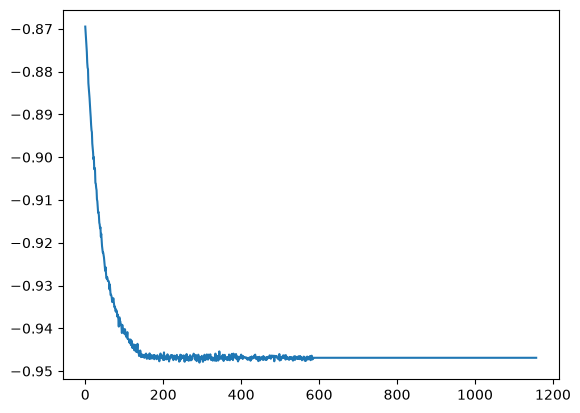

In [2]:
import matplotlib.pyplot as plt

cost_hist = load_experiment(r'C:\Users\CallumDavidson\Code\MADS\Code\Control Matrix Policy\Results\experiment_None_block_bootstrapped_6wnodes.zip')['result'].cost_history

plt.plot(cost_hist[:])

In [3]:
experiment_df = pl.DataFrame(
    [],
    schema={
        'experiment_file': pl.Utf8,
        'initial_wealth': pl.Float64,
        'n_time_nodes': pl.Int64,
        'n_wealth_nodes': pl.Int64,
        'sampler': pl.Utf8,
    }
)


for experiment_file in experiment_files:
    experiment = load_experiment(experiment_file)
    result: OptimizationResult = experiment['result']
    config: SimulationConfig = experiment['config']

    experiment_df = experiment_df.vstack(
        pl.DataFrame(
            {
                'experiment_file': [experiment_file],
                'initial_wealth': [
                    None if config.INITIAL_WEALTH is None else float(config.INITIAL_WEALTH)
                ],
                'n_time_nodes': [config.TIME_NODE_COUNT],
                'n_wealth_nodes': [config.WEALTH_NODE_COUNT],
                'sampler': [config.RETURN_SAMPLER],
            },
            schema=experiment_df.schema,
        )
    )

experiment_df.write_parquet('./Results/optimisation_experiments.parquet')

In [4]:
# Load best policy data
best_policy_df = pl.DataFrame(
    [],
    schema={
        'experiment_file': pl.Utf8,
        'time_node': pl.Float64,
        'wealth_node': pl.Float64,
        'cash': pl.Float64,
        'bonds': pl.Float64,
        'stocks': pl.Float64,
    }
)

for row in experiment_df.iter_rows(named=True):
    experiment_file = row['experiment_file']
    experiment = load_experiment(experiment_file)
    result: OptimizationResult = experiment['result']
    config: SimulationConfig = experiment['config']

    if config.TIME_NODE_COUNT > 1 and config.WEALTH_NODE_COUNT == 1:
        time_nodes = result.time_nodes
        if time_nodes is None:
            time_nodes = np.linspace(0, config.SIMULATION_YEARS, config.TIME_NODE_COUNT)

        best_policy = result.best_policy
        policy_with_cash = np.zeros((best_policy.shape[0], best_policy.shape[1] + 1))
        policy_with_cash[:, 1:] = best_policy
        policy_with_cash[:, 0] = 1 - np.sum(best_policy, axis=1)

        best_policy_df = best_policy_df.vstack(
            pl.DataFrame(
                {
                    'experiment_file': [experiment_file] * len(time_nodes),
                    'time_node': time_nodes.astype(np.float64),
                    'wealth_node': [None] * len(time_nodes),
                    'cash': policy_with_cash[:, 0],
                    'bonds': policy_with_cash[:, 1],
                    'stocks': policy_with_cash[:, 2],
                }
            )
        )

    if config.TIME_NODE_COUNT == 1 and config.WEALTH_NODE_COUNT == 1:
        best_policy = result.best_policy
        policy_with_cash = np.zeros((1, best_policy.shape[0] + 1))
        policy_with_cash[:, 1:] = best_policy
        policy_with_cash[:, 0] = 1 - np.sum(best_policy, axis=0)

        best_policy_df = best_policy_df.vstack(
            pl.DataFrame(
                {
                    'experiment_file': [experiment_file] * len(policy_with_cash),
                    'time_node': [None] * len(policy_with_cash),
                    'wealth_node': [None] * len(policy_with_cash),
                    'cash': policy_with_cash[:, 0],
                    'bonds': policy_with_cash[:, 1],
                    'stocks': policy_with_cash[:, 2],
                }
            )
        )

    if config.TIME_NODE_COUNT == 1 and config.WEALTH_NODE_COUNT > 1:
        wealth_nodes = result.wealth_nodes
        best_policy = result.best_policy
        policy_with_cash = np.zeros((best_policy.shape[0], best_policy.shape[1] + 1))
        policy_with_cash[:, 1:] = best_policy
        policy_with_cash[:, 0] = 1 - np.sum(best_policy, axis=1)

        best_policy_df = best_policy_df.vstack(
            pl.DataFrame(
                {
                    'experiment_file': [experiment_file] * len(wealth_nodes),
                    'time_node': [None] * len(wealth_nodes),
                    'wealth_node': wealth_nodes.astype(np.float64),
                    'cash': policy_with_cash[:, 0],
                    'bonds': policy_with_cash[:, 1],
                    'stocks': policy_with_cash[:, 2],
                }
            )
        )

    if config.TIME_NODE_COUNT > 1 and config.WEALTH_NODE_COUNT > 1:
        time_nodes = result.time_nodes
        wealth_nodes = result.wealth_nodes
        best_policy = result.best_policy
        # best_policy shape: (n_time_nodes, n_wealth_nodes, n_risky_assets)
        policy_with_cash = np.zeros((best_policy.shape[0], best_policy.shape[1], best_policy.shape[2] + 1))
        policy_with_cash[:, :, 1:] = best_policy
        policy_with_cash[:, :, 0] = 1 - np.sum(best_policy, axis=2)

        policy_flat = policy_with_cash.reshape(-1, policy_with_cash.shape[2])

        best_policy_df = best_policy_df.vstack(
            pl.DataFrame(
                {
                    'experiment_file': [experiment_file] * len(time_nodes) * len(wealth_nodes),
                    'time_node': np.repeat(time_nodes.astype(np.float64), len(wealth_nodes)),
                    'wealth_node': np.tile(wealth_nodes.astype(np.float64), len(time_nodes)),
                    'cash': policy_flat[:, 0],
                    'bonds': policy_flat[:, 1],
                    'stocks': policy_flat[:, 2],
                }
            )
        )

best_policy_df.write_parquet('./Results/optimisation_best_policies.parquet')

c:\Users\CallumDavidson\Code\MADS\Code\Analysis\..\utils\experiment.py:131: UserWarning: Optional array 'time_nodes' is missing from this experiment archive. This is expected for older file versions; returning None.
  self._warn_missing_optional_array("time_nodes")


In [5]:
outcomes_schema = {
    'experiment_file': pl.Utf8,
    'simulated_initial_wealth': pl.Float64,
    'n_simulations': pl.Int64,
    'bankruptcy_probability': pl.Float64,
    'bankruptcy_density': pl.Float64,
    'mean_terminal_wealth': pl.Float64,
    'std_terminal_wealth': pl.Float64,
    'median_terminal_wealth': pl.Float64,
    'p05_terminal_wealth': pl.Float64,
    'p10_terminal_wealth': pl.Float64,
    'p25_terminal_wealth': pl.Float64,
    'p75_terminal_wealth': pl.Float64,
    'p90_terminal_wealth': pl.Float64,
    'p95_terminal_wealth': pl.Float64,
}

def compute_outcome(experiment_file: str) -> pl.DataFrame:
    experiment = load_experiment(experiment_file)
    result: OptimizationResult = experiment['result']
    config: SimulationConfig = experiment['config']

    wealth = result.wealth_simulated
    initial_wealth = wealth[:, 0].astype(np.float64)
    final_wealth = wealth[:, -1].astype(np.float64)
    ruined = np.sum(wealth <= 0, axis=1) > 0
    bankruptcy_density = np.mean(wealth <= 0, axis=1)

    if config.INITIAL_WEALTH is None:
        outcome_input = pl.DataFrame(
            {
                'experiment_file': [experiment_file] * len(initial_wealth),
                'simulated_initial_wealth': initial_wealth,
                'final_wealth': final_wealth,
                'ruined': ruined,
                'bankruptcy_density_path': bankruptcy_density,
            }
        )
    else:
        outcome_input = pl.DataFrame(
            {
                'experiment_file': [experiment_file],
                'simulated_initial_wealth': [float(config.INITIAL_WEALTH)],
                'final_wealth': [final_wealth],
                'ruined': [ruined],
                'bankruptcy_density_path': [bankruptcy_density],
            }
        ).explode(['final_wealth', 'ruined', 'bankruptcy_density_path'])

    return (
        outcome_input
        .group_by(['experiment_file', 'simulated_initial_wealth'])
        .agg(
            pl.col('ruined').mean().alias('bankruptcy_probability'),
            pl.col('bankruptcy_density_path').mean().alias('bankruptcy_density'),
            pl.len().alias('n_simulations'),
            pl.col('final_wealth').mean().alias('mean_terminal_wealth'),
            pl.col('final_wealth').std(ddof=0).alias('std_terminal_wealth'),
            pl.col('final_wealth').median().alias('median_terminal_wealth'),
            pl.col('final_wealth').quantile(0.05).alias('p05_terminal_wealth'),
            pl.col('final_wealth').quantile(0.10).alias('p10_terminal_wealth'),
            pl.col('final_wealth').quantile(0.25).alias('p25_terminal_wealth'),
            pl.col('final_wealth').quantile(0.75).alias('p75_terminal_wealth'),
            pl.col('final_wealth').quantile(0.90).alias('p90_terminal_wealth'),
            pl.col('final_wealth').quantile(0.95).alias('p95_terminal_wealth'),
        )
    )


outcome_rows: list[pl.DataFrame] = []

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = [executor.submit(compute_outcome, experiment_file) for experiment_file in experiment_files]
    for future in tqdm.tqdm(
        as_completed(futures),
        total=len(futures),
        desc=f'Computing outcomes ({max_workers} threads)',
    ):
        outcome_rows.append(future.result())

outcomes_df = pl.concat(outcome_rows).sort(['experiment_file', 'simulated_initial_wealth'])
outcomes_df.write_parquet('./Results/optimisation_outcomes.parquet')

Computing outcomes (24 threads): 100%|██████████| 312/312 [00:55<00:00,  5.65it/s]


In [6]:
timeseries_data_schema = {
    'experiment_file': pl.Utf8,
    'simulated_initial_wealth': pl.Float64,
    'time_step': pl.Int64,
    'mean_wealth': pl.Float64,
    'std_wealth': pl.Float64,
    'median_wealth': pl.Float64,
    'p05_wealth': pl.Float64,
    'p10_wealth': pl.Float64,
    'p25_wealth': pl.Float64,
    'p75_wealth': pl.Float64,
    'p90_wealth': pl.Float64,
    'p95_wealth': pl.Float64,
    'bankruptcy_rate': pl.Float64,
}

def compute_timeseries(experiment_file: str) -> pl.DataFrame:
    experiment = load_experiment(experiment_file)
    result: OptimizationResult = experiment['result']
    config: SimulationConfig = experiment['config']

    wealth = result.wealth_simulated.astype(np.float64)
    n_sims, n_time_steps = wealth.shape
    time_steps = np.arange(n_time_steps, dtype=np.int64)
    initial_wealth = wealth[:, 0]

    timeseries_input = pl.DataFrame(
        {
            'experiment_file': [experiment_file] * (n_sims * n_time_steps),
            'simulated_initial_wealth': np.repeat(initial_wealth, n_time_steps),
            'time_step': np.tile(time_steps, n_sims),
            'wealth': wealth.reshape(-1),
            'is_bankrupt': (wealth <= 0).reshape(-1),
        }
    )

    if config.INITIAL_WEALTH is not None:
        timeseries_input = timeseries_input.with_columns(
            pl.lit(float(config.INITIAL_WEALTH)).alias('simulated_initial_wealth')
        )

    return (
        timeseries_input
        .group_by(['experiment_file', 'simulated_initial_wealth', 'time_step'])
        .agg(
            pl.col('wealth').mean().alias('mean_wealth'),
            pl.col('wealth').std(ddof=0).alias('std_wealth'),
            pl.col('wealth').median().alias('median_wealth'),
            pl.col('wealth').quantile(0.05).alias('p05_wealth'),
            pl.col('wealth').quantile(0.10).alias('p10_wealth'),
            pl.col('wealth').quantile(0.25).alias('p25_wealth'),
            pl.col('wealth').quantile(0.75).alias('p75_wealth'),
            pl.col('wealth').quantile(0.90).alias('p90_wealth'),
            pl.col('wealth').quantile(0.95).alias('p95_wealth'),
            pl.col('is_bankrupt').mean().alias('bankruptcy_rate'),
        )
        .select(list(timeseries_data_schema.keys()))
    )

timeseries_parts_dir = './Results/optimisation_timeseries_parts'
timeseries_parts_glob = os.path.join(timeseries_parts_dir, 'part_*.parquet')
timeseries_output_path = './Results/optimisation_timeseries.parquet'

os.makedirs(timeseries_parts_dir, exist_ok=True)
for old_part in glob.glob(timeseries_parts_glob):
    os.remove(old_part)

for idx, experiment_file in enumerate(
    tqdm.tqdm(
        experiment_files,
        total=len(experiment_files),
        desc='Computing timeseries (synchronous)',
    )
):
    part_df = compute_timeseries(experiment_file).sort(
        ['experiment_file', 'simulated_initial_wealth', 'time_step']
    )
    part_path = os.path.join(timeseries_parts_dir, f'part_{idx:05d}.parquet')
    part_df.write_parquet(part_path)

pl.scan_parquet(timeseries_parts_glob).sort(
    ['experiment_file', 'simulated_initial_wealth', 'time_step']
).sink_parquet(timeseries_output_path)

timeseries_df = pl.read_parquet(timeseries_output_path)

Computing timeseries (synchronous): 100%|██████████| 312/312 [12:10<00:00,  2.34s/it]


In [7]:
timeseries_df

experiment_file,simulated_initial_wealth,time_step,mean_wealth,std_wealth,median_wealth,p05_wealth,p10_wealth,p25_wealth,p75_wealth,p90_wealth,p95_wealth,bankruptcy_rate
str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""../Control Matrix Policy/Resul…",500000.0,0,500000.0,0.0,500000.0,500000.0,500000.0,500000.0,500000.0,500000.0,500000.0,0.0
"""../Control Matrix Policy/Resul…",500000.0,1,496081.979308,89028.552588,492682.12594,386162.103292,421980.968285,458357.680995,533141.990491,572547.99151,598912.8193,0.000577
"""../Control Matrix Policy/Resul…",500000.0,2,491164.991029,137598.506678,481584.739485,312554.274385,376486.942867,428403.799617,551433.793374,614298.932069,654886.28559,0.001237
"""../Control Matrix Policy/Resul…",500000.0,3,484630.326654,196498.977892,466760.308429,272031.774474,331962.841681,401325.782537,560358.285537,647040.818332,701869.465359,0.002255
"""../Control Matrix Policy/Resul…",500000.0,4,477214.447233,239741.903628,450511.95573,233228.881379,289590.706151,374337.32139,561867.526621,675951.71739,739460.368345,0.00407
…,…,…,…,…,…,…,…,…,…,…,…,…
"""../Time Responsive Policy/Resu…",1e6,31,3.2098e6,3.7091e6,2.1128e6,4.3673e-12,238297.551853,883733.183393,4.1999e6,7.3331e6,9.9967e6,0.043011
"""../Time Responsive Policy/Resu…",1e6,32,3.3936e6,4.0122e6,2.2080e6,3.4774e-12,226195.421856,907252.404529,4.3978e6,7.7975e6,1.0722e7,0.045128
"""../Time Responsive Policy/Resu…",1e6,33,3.5967e6,4.3535e6,2.3088e6,1.9903e-12,214064.191799,922783.753657,4.6462e6,8.3338e6,1.1464e7,0.048428
